# Exercise 2: Poisson Equation

Solve the 2D Poisson equation for the gravitational potential Φ of a uniform-density disk: 

\begin{equation*}
    \nabla^2\phi = 4\pi G \rho(x,y),
\end{equation*}

with density:

\begin{equation*}
    \rho(x, y) =
    \begin{cases}
        \rho_0 & \mathrm{if}\, r = \sqrt{x^2+y^2} < R\\
        0 & \mathrm{otherwise}.
    \end{cases}
\end{equation*}

Use units where $4πGρ0 = 1$ and $R = 1$. The computational domain is $[−L, L] × [−L, L]$ with
$L = 3R$. 

Dirichlet boundary conditions are imposed using the analytic solution evaluated at the
boundary points.


With $4πGρ0 = 1$, the Poisson equation reduces to:

\begin{equation*}
    \begin{cases}
        \nabla^2 \phi = 1 & \mathrm{inside\,the\,disk}\\
        \nabla^2 \phi = 0 & \mathrm{outside\,the\,disk}
    \end{cases}
\end{equation*}

Using radial symmetry, the general solutions are:

\begin{equation*}
    \begin{cases}
        \mathrm{inside\,(r \leq R)}: & \phi = \frac{r^2}{4} +  C_{\mathrm{in}} \\
        \mathrm{outside\,(r > R)}: & \phi = \frac{R^2}{2}\ln{(r)} +  C_{\mathrm{out}}
    \end{cases}
\end{equation*}

The two constants are fixed by continuity of $\phi$ and $d\phi/dr$ at $r = R$. Matching derivatives: $\rm d\phi_{in}/dr = r/2$ and $\rm d\phi_{out}/dr = R^2/(2r)$, both equal $R/2$ at $r = R$, so the derivative condition is automatically satisfied. Continuity of $\phi$ at $r = R$ then gives one relation, and we choose the normalization $\phi(R) = 0$. With $R = 1$:

\begin{equation*}
    C_{\mathrm{in}} = -1/4 \,\,\,\,\,\,\,\,\,\,\,\,\,\, C_{\mathrm{out}} = 0.
\end{equation*}

Therefore, the complete analytical solution is given by:


\begin{equation*}
    \begin{cases}
        \mathrm{inside\,(r \leq R)}: & \phi = \frac{1}{4}(r^2-1) \\
        \mathrm{outside\,(r > R)}: & \phi = \frac{1}{2}\ln{(r)}
    \end{cases}
\end{equation*}

Note: inside, $\phi$ is parabolic in $r$ with minimum $-1/4$ at the centre. Outside, $\phi$ grows logarithmically. The slope is continuous at $r=1$ with $\rm d\phi/dr=1/2$ there.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def phi_true(r):
    """
    Analytical solution of the Poisson equation.

    matrix (float) r: radius on (x,y) grid

    returns:
    matrix (float) phi_true: phi(r) on (x,y) grid
    """
    phi_t = np.zeros_like(r)
    
    phi_t[r < R] = (r[r < R]**2 - 1.0) / 4.0
    phi_t[r > R] = 0.5 * np.log(r[r > R])

    return phi_t

In [3]:
def apply_bc(phi, phi_bc):
    """
    Apply Dirichlet boundary conditions on state vector based on analytical solution with boundaries applied.
    
    matrix (float) phi: current state vector on grid (x,y) w/o boundary conditions
    matrix (float) phi_bc: 

    returns:
    matrix (float) phi_work: current state vector on grid (x,y) with boundary conditions applied 
    """
    phi_work = phi.copy()

    phi_work[0, :] = phi_bc[0,:]
    phi_work[-1, :] = phi_bc[-1,:]
    phi_work[:, 0] = phi_bc[:, 0]
    phi_work[:, -1] = phi_bc[:, -1]
        
    return phi_work

def compute_residual(phi, S, h):
    """
    Compute residuals between current state vector and the source to evaluate violation of the Poisson equation.
    
    matrix (float) phi: current state vector on (x,y) grid
    matrix (float) S: source on (x,y) grid
    float h: dx = dy grid step

    returns:
    matrix (float) res: residuals on (x,y) grid
    """
    res = np.zeros_like(phi)
    phi_work = phi.copy()
    res = np.roll(phi_work, -1, axis = 0) + np.roll(phi_work, 1, axis = 0) + np.roll(phi_work, -1, axis = 1) + np.roll(phi_work, 1, axis = 1)
    res = res - 4*phi_work - h**2*S

    res = apply_bc(res, S)  #avoid using boundaries to set maximum residual
    return res


In [4]:
def jacobi(source, phi, h):
    """
    Jacobi iteration for the Poisson equation.

    matrix (float) source: source in grid (x,y)
    matrix (float) phi: current state vector in grid (x,y)
    float h: dx = dy grid step

    returns:
    matrix (float) phi_work: evolved state vector in grid (x,y)
    """
    phi_work = phi.copy()
    
    phi_work = 1/4*(np.roll(phi, -1, axis = 0) + np.roll(phi, +1, axis = 0) + np.roll(phi, -1, axis = 1) + np.roll(phi, +1, axis = 1) - h**2*source)

    return phi_work

def gauss_seidel(source, phi, h):
    """
    Gauss-Seidel iteration for the Poisson equation.

    matrix (float) source: source in grid (x,y)
    matrix (float) phi: current state vector in grid (x,y)
    float h: dx = dy grid step

    returns:
    matrix (float) phi_work: evolved state vector in grid (x,y)
    """
    phi_work = phi.copy()
    #need to do gauss seidel steps separately (can't use np.roll)
    for i in range(1, nx-1):
        for j in range(1, nx-1):
            phi_work[i, j] = 1/4*(phi_work[i+1, j] + phi_work[i-1, j] + phi_work[i, j+1] + phi_work[i, j-1] - h**2 * source[i, j])
    return phi_work

def SOR(source, phi, h, omega):
    """
    SOR iteration for the Poisson equation.

    matrix (float) source: source in grid (x,y)
    matrix (float) phi: current state vector in grid (x,y)
    float h: dx = dy grid step
    float omega: correction factor

    returns:
    matrix (float) phi_work: evolved state vector in grid (x,y)
    """
    phi_work = phi.copy()
    #need to do gauss seidel steps separately (can't use np.roll)
    for i in range(1, nx-1):
        for j in range(1, nx-1):
            phi_star = 1/4*(phi_work[i+1, j] + phi_work[i-1, j] + phi_work[i, j+1] + phi_work[i, j-1] - h**2 * source[i, j])
            phi_work[i, j] = (1 - omega) * phi_work[i, j] + omega * phi_star
    return phi_work

In [5]:
def model(nx, A, p):
    """ 
    Model function to obtain the slope of the error curve in log-log scale.
    array (float) n: grid size (on 1 dimension)
    float A: constant factor
    float p: order of the method (slope in log-log scale)

    returns:
    array (float): estimated errors from step size
    """
    return A*nx**p

In [6]:
G = 6.67430e-11        
rho = 1/(4*np.pi*G)
R = 1.
L = 3.
nx = 51
x = np.linspace(-L, L, nx)
y = np.linspace(-L, L, nx)
h = x[1]-x[0]

In [7]:
X, Y = np.meshgrid(x,y, indexing='ij')
r = np.sqrt(X**2+Y**2)

phi_exact = phi_true(r)
source = np.zeros((nx, nx))
source[r < R] = 4*np.pi*G*rho

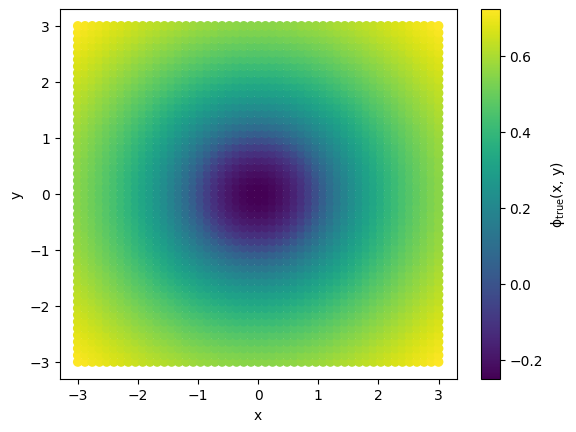

In [8]:
plt.scatter(X, Y, c = phi_exact)
plt.colorbar(label = r'$\rm\phi_{true}$(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### 1. Implement Jacobi, Gauss-Seidel and SOR on the 2D grid (+ 2., 3. and 4.)

For all three schemes I make use of the analytical solution to impose the boundary conditions. The boundary conditions are given by:

\begin{equation*}
    \phi_{\mathrm{out}}(r) =   \frac{1}{2} \ln(r),
\end{equation*}

hence, the boundary values depend only on the distance from the origin. Since the analytical solution is computed on the same computational grid adopted for the numerical methods, the boundary nodes of the numerical solution can be assigned directly from the analytical solution at the corresponding grid points during each iteration.

All schemes are iterated until the condition $\rm max_{i,j}|R_{i,j}| < 10^{-6}$ is satisfied.

In [9]:
phi_jacobi = np.zeros_like(phi_exact)
phi_jacobi = apply_bc(phi_jacobi, phi_exact)
phi_old = phi_exact.copy()

err = 1.
i = 0
while err > 1e-6:
    phi_jacobi = jacobi(source, phi_jacobi, h)
    phi_jacobi = apply_bc(phi_jacobi, phi_exact)
    
    err = np.max(np.abs(compute_residual(phi_old, source, h)))
    phi_old = phi_jacobi.copy()
    i = i+1

print('Number of iterations:', i)

Number of iterations: 4030


In [10]:
phi_gs = np.zeros_like(phi_exact)
phi_gs = apply_bc(phi_gs, phi_exact)
phi_old = phi_exact.copy()

err = 1.
i = 0
while err > 1e-6:
    phi_gs = gauss_seidel(source, phi_gs, h)
    phi_gs = apply_bc(phi_gs, phi_exact)
    
    err = np.max(np.abs(compute_residual(phi_old, source, h)))
    phi_old = phi_gs.copy()
    i = i+1

print('Number of iterations:', i)

Number of iterations: 2012


For SOR, I implement $\rm \omega_{opt} = 2/(1+\sin{\pi/N})$, where $N$ here is the size of the interior grid with uniform spacing.

In [11]:
phi_sor = np.zeros_like(phi_exact)
phi_sor = apply_bc(phi_sor, phi_exact)
phi_old = phi_exact.copy()

err = 1.
i = 0
omega = 2/(1+np.sin(np.pi/(nx-2)))
while err > 1e-6:
    phi_sor = SOR(source, phi_sor, h, omega)
    phi_sor = apply_bc(phi_sor, phi_exact)
    
    err = np.max(np.abs(compute_residual(phi_old, source, h)))
    phi_old = phi_sor.copy()
    i = i+1

print('Number of iterations:', i)

Number of iterations: 120


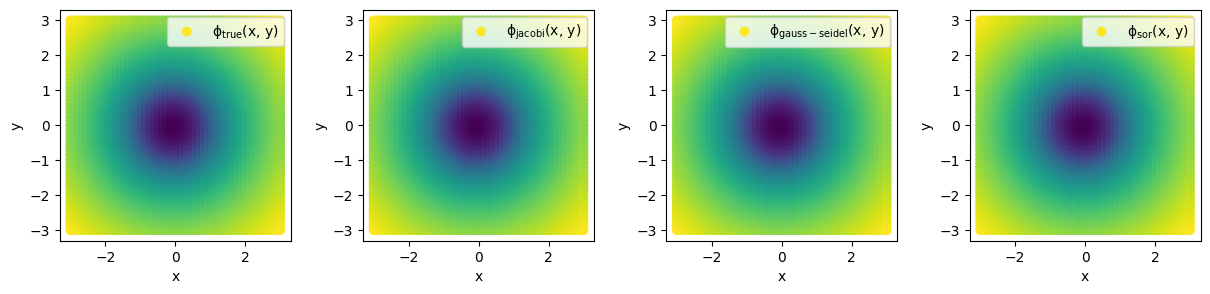

In [12]:
fig = plt.figure(figsize = (15, 3))
ax = fig.add_subplot(141)
ax.scatter(X, Y, c = phi_exact, label = r'$\rm\phi_{true}$(x, y)')
#ax.set_colorbar(label = r'$\rm\phi_{true}$(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_aspect('equal')

ax = fig.add_subplot(142)
ax.scatter(X, Y, c = phi_jacobi, label = r'$\rm\phi_{jacobi}$(x, y)')
#ax.set_colorbar(label = r'$\rm\phi_{true}$(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_aspect('equal')

ax = fig.add_subplot(143)
ax.scatter(X, Y, c = phi_gs, label = r'$\rm\phi_{gauss-seidel}$(x, y)')
#ax.set_colorbar(label = r'$\rm\phi_{true}$(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_aspect('equal')

ax = fig.add_subplot(144)
ax.scatter(X, Y, c = phi_sor, label = r'$\rm\phi_{sor}$(x, y)')
#ax.set_colorbar(label = r'$\rm\phi_{true}$(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_aspect('equal')

### 6. Comparison with Analytical Solution
Compare the converged $\Phi(x, 0)$ along the x-axis to the analytic result. Plot both and
report the maximum pointwise error.

Check at y around zero: -0.7200000000000002 -0.6000000000000001
--------------- Checking y = -0.7200000000000002 ---------------
Maximum error (Jacobi): 0.009474334069229096
Maximum error (Gauss-Seidel): 0.009477619944598031
Maximum error (SOR): 0.009383903761777168

--------------- Checking y = -0.6000000000000001 ---------------
Maximum error (Jacobi): 0.009066363461871313
Maximum error (Gauss-Seidel): 0.009069492248130723
Maximum error (SOR): 0.008972625788153665



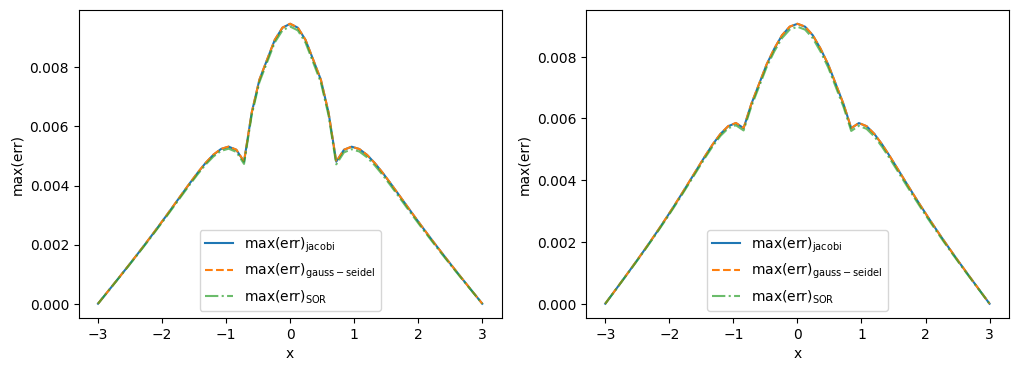

In [13]:
print('Check at y around zero:', y[19], y[20])

indeces = [19,20]
fig = plt.figure(figsize=(12,4))
for i, idx in enumerate(indeces):
    print('--------------- Checking y = ' + str(y[idx]) + ' ---------------')
    ax = fig.add_subplot(121+i)
    err_jacobi = np.abs(phi_jacobi[:, idx] - phi_exact[:, idx])
    err_gs = np.abs(phi_gs[:, idx] - phi_exact[:, idx])
    err_sor = np.abs(phi_sor[:, idx] - phi_exact[:, idx])

    print('Maximum error (Jacobi):', np.max(err_jacobi))
    print('Maximum error (Gauss-Seidel):', np.max(err_gs))
    print('Maximum error (SOR):', np.max(err_sor))
    
    ax.plot(x, err_jacobi, label = r'$\rm max(err)_{jacobi}$')
    ax.plot(x, err_gs, linestyle = '--', label = r'$\rm max(err)_{gauss-seidel}$')
    ax.plot(x, err_sor, linestyle = '-.', alpha = 0.7, label = r'$\rm max(err)_{SOR}$')
    ax.set_xlabel('x')
    ax.set_ylabel('max(err)')
    ax.legend()
    print('')

### 5. Count iterations to Convergence
Count iterations to convergence for all three methods with  $N = [20, 40, 80]$. Tabulate the
results and verify the $\mathcal{O}(N^2)$ vs $\mathcal{O}(N)$ scaling.

In [14]:
N = [20, 40, 80]

diff_list = []
err_list = []
errs = []
diff = []
for nx in N:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_jacobi = np.zeros_like(phi_exact)
    phi_jacobi = apply_bc(phi_jacobi, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while err > 1e-6:
        phi_jacobi = jacobi(source, phi_jacobi, h)
        phi_jacobi = apply_bc(phi_jacobi, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_jacobi.copy()
        i = i+1
        
    print('Number of iterations:', i)    
    diff.append(i)
    err = np.max(np.abs(phi_jacobi-phi_exact))
    errs.append(err)

diff_list.append(diff)
err_list.append(errs)

Number of iterations: 718


Number of iterations: 2632
Number of iterations: 8919


In [15]:
N = [20, 40, 80]

diff = []
errs = []
for nx in N:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_gs = np.zeros_like(phi_exact)
    phi_gs = apply_bc(phi_gs, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while err > 1e-6:
        phi_gs = gauss_seidel(source, phi_gs, h)
        phi_gs = apply_bc(phi_gs, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_gs.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_gs-phi_exact))
    diff.append(i)
    errs.append(err)

diff_list.append(diff)
err_list.append(errs)

Number of iterations: 362
Number of iterations: 1318
Number of iterations: 4462


In [16]:
N = [20, 40, 80]

diff = []
errs = []
for nx in N:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_sor = np.zeros_like(phi_exact)
    phi_sor = apply_bc(phi_sor, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    omega = 2/(1+np.sin(np.pi/nx))
    while err > 1e-6:
        phi_sor = SOR(source, phi_sor, h, omega)
        phi_sor = apply_bc(phi_sor, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_sor.copy()
        i = i+1

    print('Number of iterations:', i)
    
    diff.append(i)

    err = np.max(np.abs(phi_sor-phi_exact))
    errs.append(err)

diff_list.append(diff)
err_list.append(errs)

Number of iterations: 52
Number of iterations: 99
Number of iterations: 195


### 7. Bonus
Plot the convergence history (log of max residual vs iteration count) for all three
methods and read off the convergence rate from the slope.


In [17]:
N_iter = [50, 100, 500, 1000, 5000, 10000]
nx = 40

err_list = []
errs = []
for max_iter in N_iter:
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)
    h = x[1]-x[0]
    
    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_jacobi = np.zeros_like(phi_exact)
    phi_jacobi = apply_bc(phi_jacobi, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while i < max_iter:
        phi_jacobi = jacobi(source, phi_jacobi, h)
        phi_jacobi = apply_bc(phi_jacobi, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_jacobi.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_jacobi-phi_exact))
    errs.append(err)

err_list.append(errs)

Number of iterations: 50
Number of iterations: 100
Number of iterations: 500
Number of iterations: 1000
Number of iterations: 5000
Number of iterations: 10000


In [18]:
diff = []
errs = []
for max_iter in N_iter:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_gs = np.zeros_like(phi_exact)
    phi_gs = apply_bc(phi_gs, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    while i < max_iter:
        phi_gs = gauss_seidel(source, phi_gs, h)
        phi_gs = apply_bc(phi_gs, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_gs.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_gs-phi_exact))
    errs.append(err)

err_list.append(errs)

Number of iterations: 50
Number of iterations: 100
Number of iterations: 500
Number of iterations: 1000
Number of iterations: 5000
Number of iterations: 10000


In [19]:
errs = []
for max_iter in N_iter:
    h = 2.0*L/(nx - 1)
    x = np.linspace(-L, L, nx)
    y = np.linspace(-L, L, nx)

    X, Y = np.meshgrid(x,y, indexing='ij')
    r = np.sqrt(X**2+Y**2)
    source = np.zeros((nx, nx))
    source[r < R] = 4*np.pi*G*rho

    phi_exact = phi_true(r)

    phi_sor = np.zeros_like(phi_exact)
    phi_sor = apply_bc(phi_sor, phi_exact)
    phi_old = phi_exact.copy()

    err = 1.
    i = 0
    omega = 2/(1+np.sin(np.pi/(nx-2)))
    while i < max_iter:
        phi_sor = SOR(source, phi_sor, h, omega)
        phi_sor = apply_bc(phi_sor, phi_exact)
        
        err = np.max(np.abs(compute_residual(phi_old, source, h)))
        phi_old = phi_sor.copy()
        i = i+1

    print('Number of iterations:', i)
    err = np.max(np.abs(phi_sor-phi_exact))
    errs.append(err)

err_list.append(errs)

Number of iterations: 50
Number of iterations: 100
Number of iterations: 500
Number of iterations: 1000
Number of iterations: 5000
Number of iterations: 10000


In [20]:
N = np.array(N)
N_iter = np.array(N_iter)
diff_list = np.array(diff_list)
err_list = np.array(err_list)

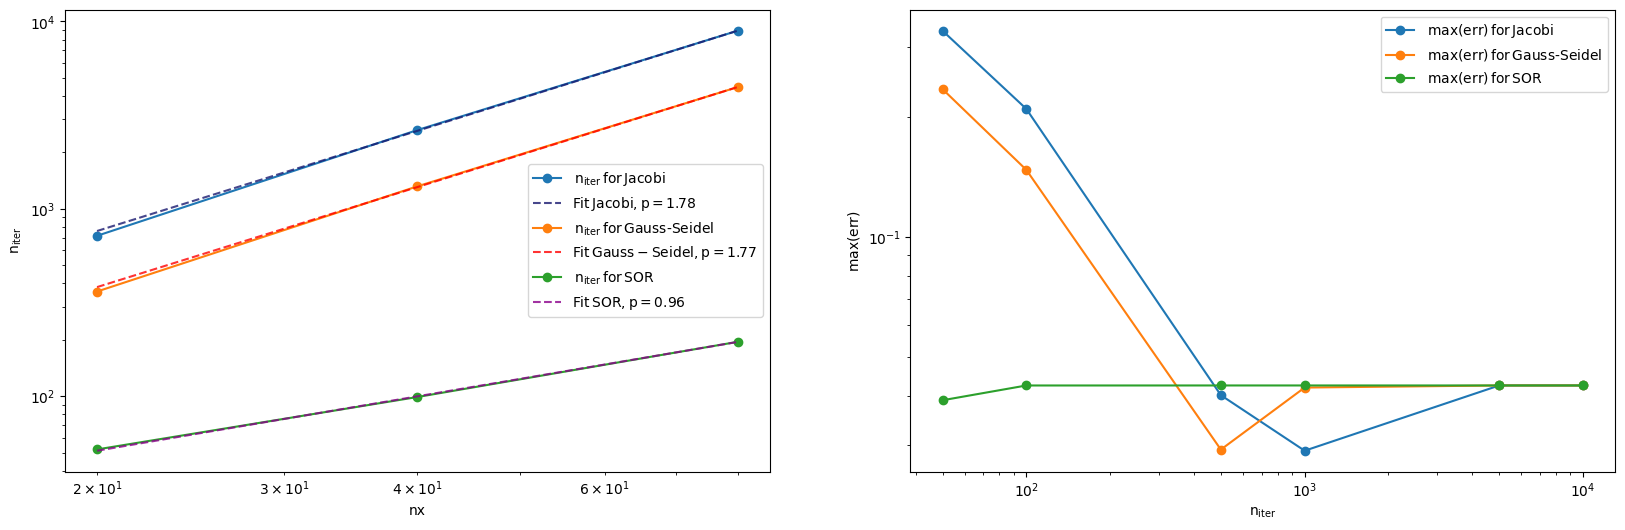

In [21]:
fig = plt.figure(figsize = (20, 6))
ax = fig.add_subplot(121)

colors = ['midnightblue', 'red', 'darkmagenta']
labels = ['Jacobi', 'Gauss-Seidel', 'SOR']
for i in range(len(diff_list)):
    ax.loglog(N, diff_list[i], 'o-', label =  r'$\,\rm n_{iter}\, for\,$' +labels[i] )

    params, _ = curve_fit(model, N, diff_list[i])
    A_fit, p_fit = params
    ax.loglog(N, model(N, A_fit, p_fit), color = colors[i], linestyle = '--', alpha = 0.8, label=rf'$\rm Fit\, '+ labels[i]+f', p = {p_fit:.2f} $')
ax.set_xlabel('nx')
ax.set_ylabel(r'$\,\rm n_{iter}$')
ax.legend()


ax = fig.add_subplot(122)
for i in range(len(diff_list)):
    ax.loglog(N_iter, err_list[i], 'o-', label =  r'$\,\rm max(err)\, for\,$' +labels[i])
ax.set_xlabel(r'$\rm n_{iter}$')
ax.set_ylabel(r'$\rm max(err)$')
ax.legend()

plt.show()